In [1]:
import torch
import torchvision
import torchvision.transforms as transforms

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
batch_size = 4

In [3]:
from pathlib import Path
import os

modal_dir = "data"
Path(f"{os.getcwd()}/{modal_dir}").mkdir(exist_ok=True)

In [4]:
trainset = torchvision.datasets.CIFAR10(
    root=modal_dir,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

In [6]:
classes = (
    'plane', 'car', 'bird', 'cat', 'deer', 
    'dog', 'frog', 'horse', 'ship', 'truck'
)

**View some training Images**

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

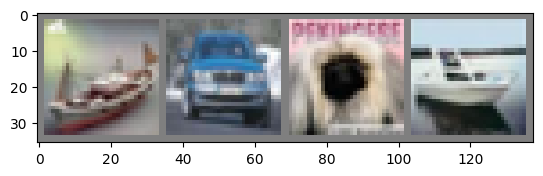

ship  car   dog   ship 


In [ ]:
# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

**Import the Sample Neural network**

In [8]:
from sample_neural_network import Net

net = Net(learning_rate=0.01)

In [16]:
for epoch in range(20):

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        loss = net.training_step(inputs, target=labels)

        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

## Save modal weights
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)


[1,  2000] loss: 1.926
[1,  4000] loss: 2.009
[1,  6000] loss: 1.942
[1,  8000] loss: 1.977
[1, 10000] loss: 1.939
[1, 12000] loss: 1.968
[2,  2000] loss: 1.982
[2,  4000] loss: 1.986
[2,  6000] loss: 1.981
[2,  8000] loss: 1.963
[2, 10000] loss: 1.965
[2, 12000] loss: 1.986
[3,  2000] loss: 1.973
[3,  4000] loss: 1.964
[3,  6000] loss: 1.957
[3,  8000] loss: 1.956
[3, 10000] loss: 1.941
[3, 12000] loss: 1.961
[4,  2000] loss: 1.938
[4,  4000] loss: 1.951
[4,  6000] loss: 1.968
[4,  8000] loss: 1.953
[4, 10000] loss: 1.981
[4, 12000] loss: 1.991
[5,  2000] loss: 1.958
[5,  4000] loss: 1.997
[5,  6000] loss: 1.960
[5,  8000] loss: 1.960
[5, 10000] loss: 1.963
[5, 12000] loss: 1.987
[6,  2000] loss: 1.990
[6,  4000] loss: 1.954
[6,  6000] loss: 1.963
[6,  8000] loss: 1.956
[6, 10000] loss: 1.965
[6, 12000] loss: 1.958
[7,  2000] loss: 1.958
[7,  4000] loss: 1.940
[7,  6000] loss: 1.951
[7,  8000] loss: 1.957
[7, 10000] loss: 1.963
[7, 12000] loss: 1.976
[8,  2000] loss: 1.955
[8,  4000] 

**Testing the Modal**

In [20]:
from sample_neural_network import Net

net = Net(learning_rate=0.01)

PATH = './cifar_net.pth'
# net.load_weights(PATH)
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [5]:
testset = torchvision.datasets.CIFAR10(
    root=modal_dir,
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

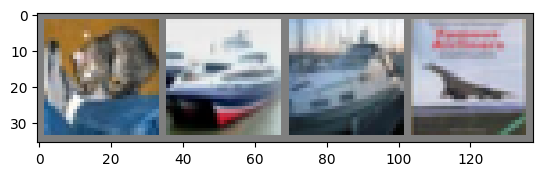

GroundTruth:  cat   ship  ship  plane


In [11]:
dataiter = iter(testloader)
test_images, test_labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(test_images))
print('GroundTruth: ', ' '.join(f'{classes[test_labels[j]]:5s}' for j in range(4)))

In [12]:
outputs = net.run(test_images)

In [13]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))

Predicted:  frog  plane plane ship 


In [14]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data

        # calculate outputs by running images through the network
        outputs = net.run(images)

        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')


Accuracy of the network on the 10000 test images: 27 %


In [21]:
# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net.run(images)

        _, predictions = torch.max(outputs, 1)

        # collect the correct predictions for each class
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1

# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: plane is 18.1 %
Accuracy for class: car   is 63.5 %
Accuracy for class: bird  is 3.2 %
Accuracy for class: cat   is 0.8 %
Accuracy for class: deer  is 1.6 %
Accuracy for class: dog   is 50.0 %
Accuracy for class: frog  is 26.9 %
Accuracy for class: horse is 36.5 %
Accuracy for class: ship  is 17.4 %
Accuracy for class: truck is 15.8 %
